First of all, set the 'CODE_DIR' to where the model code are saved. This will change current working directory and print for checking. Afterwards, we import all required modules.

In [1]:
import os

os.environ["TORCH_CUDA_ARCH_LIST"] = "8.0"
os.environ["CUDA_HOME"] = "/usr/local/cuda-12.5"
os.environ["PATH"] = "/usr/local/cuda-12.5/bin:" + os.environ["PATH"]
os.environ["LD_LIBRARY_PATH"] = "/usr/local/cuda-12.5/lib64:" + os.environ.get("LD_LIBRARY_PATH", "")


In [2]:
#@title Setup Repository
import os

CODE_DIR = '/home/ids/yuhe/Projects/CA_with_GAN/3_code/styleGAN/encoder4editing-main'

os.chdir(f'{CODE_DIR}')

from argparse import Namespace
import time
import os
import sys
import numpy as np
from PIL import Image
import torch
import torchvision.transforms as transforms

sys.path.append(".")
sys.path.append("..")

from utils.common import tensor2im
from models.psp import pSp  # we use the pSp framework to load the e4e encoder.

%load_ext autoreload
%autoreload 2

ImportError: cannot import name 'DiagnosticOptions' from 'torch.onnx._internal.exporter' (/home/ids/yuhe/anaconda3/envs/styleGANenv/lib/python3.11/site-packages/torch/onnx/_internal/exporter/__init__.py)

In [3]:
experiment_type = 'horse_encode' #@param ['ffhq_encode', 'cars_encode', 'horse_encode', 'church_encode']

EXPERIMENT_DATA_ARGS = {
    "ffhq_encode": {
        "model_path": "../pretrained_models/e4e_ffhq_encode.pt",
        "image_path": "notebooks/images/input_img.jpg"
    },
    "cars_encode": {
        "model_path": "../pretrained_models/e4e_models/e4e_cars_encode.pt",
        "image_path": "notebooks/images/car_img.jpg"
    },
    "horse_encode": {
        "model_path": "../pretrained_models/e4e_models/e4e_horse_encode.pt",
        "image_path": "/home/ids/yuhe/Projects/CA_with_GAN/3_code/styleGAN/encoder4editing-main/notebooks/images/horse_img.jpg"
    },
    "church_encode": {
        "model_path": "../pretrained_models/e4e_models/e4e_church_encode.pt",
        "image_path": "notebooks/images/church_img.jpg"
    }
    
}
# Setup required image transformations
EXPERIMENT_ARGS = EXPERIMENT_DATA_ARGS[experiment_type]
if experiment_type == 'cars_encode':
    EXPERIMENT_ARGS['transform'] = transforms.Compose([
            transforms.Resize((192, 256)),
            transforms.ToTensor(),
            transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])])
    resize_dims = (256, 192)
else:
    EXPERIMENT_ARGS['transform'] = transforms.Compose([
        transforms.Resize((256, 256)),
        transforms.ToTensor(),
        transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])])
    resize_dims = (256, 256)

In [4]:
model_path = EXPERIMENT_ARGS['model_path']
ckpt = torch.load(model_path, map_location='cpu')
opts = ckpt['opts']
# pprint.pprint(opts)  # Display full options used
# update the training options
opts['checkpoint_path'] = model_path
opts= Namespace(**opts)
net = pSp(opts)
net.eval()
net.cuda()
print('Model successfully loaded!')

Loading e4e over the pSp framework from checkpoint: ../pretrained_models/e4e_models/e4e_horse_encode.pt
Model successfully loaded!


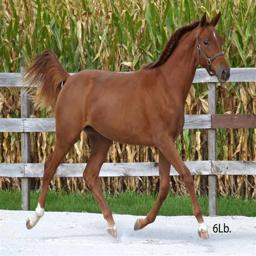

In [5]:
image_path = EXPERIMENT_DATA_ARGS[experiment_type]["image_path"]
original_image = Image.open(image_path)
original_image = original_image.convert("RGB")

def run_alignment(image_path):
  import dlib
  from utils.alignment import align_face
  predictor = dlib.shape_predictor("shape_predictor_68_face_landmarks.dat")
  aligned_image = align_face(filepath=image_path, predictor=predictor) 
  print("Aligned image has shape: {}".format(aligned_image.size))
  return aligned_image 

if experiment_type == "ffhq_encode":
  input_image = run_alignment(image_path)
else:
  input_image = original_image

input_image.resize(resize_dims)

### Load pretrained pSp model

Inference took 0.4638 seconds.


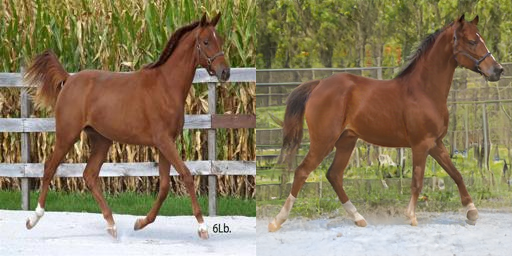

In [6]:
img_transforms = EXPERIMENT_ARGS['transform']
transformed_image = img_transforms(input_image)

def display_alongside_source_image(result_image, source_image):
    res = np.concatenate([np.array(source_image.resize(resize_dims)),
                          np.array(result_image.resize(resize_dims))], axis=1)
    return Image.fromarray(res)

def run_on_batch(inputs, net):
    images, latents = net(inputs.to("cuda").float(), randomize_noise=False, return_latents=True)
    if experiment_type == 'cars_encode':
        images = images[:, :, 32:224, :]
    return images, latents

with torch.no_grad():
    tic = time.time()
    images, latents = run_on_batch(transformed_image.unsqueeze(0), net)
    result_image, latent = images[0], latents[0]
    toc = time.time()
    print('Inference took {:.4f} seconds.'.format(toc - tic))

# Display inversion:
display_alongside_source_image(tensor2im(result_image), input_image)